# Cross-resistance on the allele-frequency dataset

> **What the graphs show.** This panel reproduces the same shared-driver edges as the original dataset (`burden_f420_activation` -> delamanid/pretomanid, efflux variants -> bedaquiline/clofazimine). The agnostic joint graph also throws up one feature (`mtra_Leu120Arg`) that points into every drug at once. The linezolid control flags this as an artifact rather than a real driver (see below).

Same design as the original-data cross-resistance notebook. The only change is how features are built: mutations are allele frequencies turned into 0/1 at a >= 5% threshold, over a wider gene panel that adds the regulatory genes `ndh`, `mtrA`, `mtrB`, `lpqB`. A wider panel can surface new drivers, but can also let in features that just track how strains are grouped rather than resistance itself. Catching that is exactly what the linezolid negative control is for.

Resistance *type* is excluded for the same reason as before: the type label is defined from resistance to other drugs, so it sits below those MICs rather than above them.

**How to read the graphs.** An arrow X -> MIC means X is picked as a direct input to that MIC once every other node is accounted for. The number is how often the edge survives when the model is refit on random 80% subsamples (higher = more reliable; 0.5 or above treated as solid).

**Node colours.** salmon = drug MIC (outcome), blue = single mutation, orange = pooled variant burden, grey = lineage, khaki = resistance type.

## What the burdens are, and how they were pooled

Most variants show up in very few strains (< 5% each), too rare to fit on their own. So within each predefined gene group, the **rare non-synonymous variants are collapsed into a single binary column** (the *burden*): it is 1 for a strain that carries any such variant in that group's genes, and 0 otherwise. Common variants are kept as their own nodes; synonymous variants are dropped. This swaps "which exact variant" for "is this group hit at all", which is the level of detail the data can actually support when each variant alone is too sparse to model.

- **`burden_f420_activation`** pools rare variants across `ddn`, `fgd1`, `fbiA`, `fbiB`, `fbiC`, `fbiD`.
- **`burden_efflux`** pools rare variants across `rv0678`, `mmpL5`, `mmpS5`, `pepQ`, `rv1979c`.

The group names are just labels for the pooled column; each burden then enters the graph as an ordinary binary feature.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of, parents_across, plot_parents_across

/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Joint graph, all drugs (agnostic)

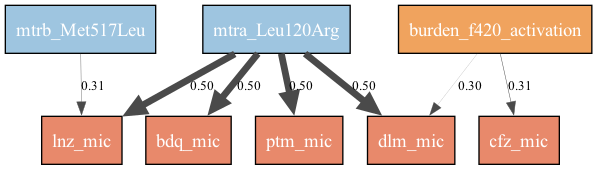

In [2]:
show_graph('tb_multidrug_freq_dlm_ptm_bdq_cfz_lnz', ['dlm_mic','ptm_mic','bdq_mic','cfz_mic','lnz_mic'], 0.3)

## The negative control catches an artifact

`mtra_Leu120Arg` points into **all five** MICs at 0.50, including the linezolid MIC, which has no resistant strains to drive. Yet its plain correlation with each MIC is about 0. So this edge is not a shared driver: the variant simply tracks how strains are grouped (it co-occurs with `lpqb_Val309Gly` and follows the lineage column), and that grouping leaks into every MIC at once. Because a real resistance signal cannot run through a drug with no resistance, the linezolid control catches it. The point is methodological: the added regulatory genes need vetting before they are trusted in an agnostic graph.

## Focused graphs replicate the findings

Dropping the new regulatory genes, the focused per-group graphs hold up, and sharpen, under frequency calling.

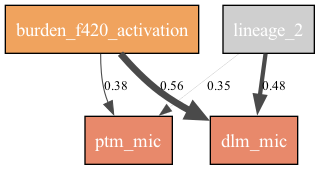

In [3]:
show_graph('tb_multidrug_freq_focused_f420_dlm_ptm', ['dlm_mic', 'ptm_mic'])

In [4]:
parents_of('tb_multidrug_freq_focused_f420_dlm_ptm', 'dlm_mic')

,source,frequency
0,burden_f420_activation,0.56
1,lineage_2,0.48
2,lineage_4,0.18


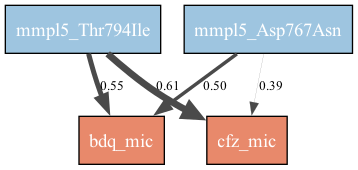

In [5]:
show_graph('tb_multidrug_freq_focused_efflux_bdq_cfz', ['bdq_mic', 'cfz_mic'])

In [6]:
parents_of('tb_multidrug_freq_focused_efflux_bdq_cfz', 'bdq_mic')

,source,frequency
0,mmpl5_Thr794Ile,0.55
1,mmpl5_Asp767Asn,0.50
2,burden_efflux,0.29
3,pepq_Ala87Gly,0.26
4,lineage_4,0.15
5,lineage_2,0.10


## Reading the results

- Focused `burden_f420_activation -> delamanid` replicates (reliability ~0.56) and reaches pretomanid.
- The efflux edge sharpens: `mmpl5_Thr794Ile` now clears 0.5 into both bedaquiline and clofazimine, a single clean shared-driver edge.
- Trust the focused graphs on this panel. The agnostic joint graph here is confounded by the regulatory-gene artifact above, so the frequency data helps the focused, per-group graphs more than the agnostic one.